## Parallel Workflows in LangGraph

### 1. Simple Parallel workflow for cricket player
```mermaid
graph TD
    A([START]) --> B([Strike Rate])
    A --> C([Boundary Percentage])
    A --> D([Balls Per Boundary])
    B --> E([Summary])
    C --> E
    D --> E

    style A fill:#4CAF50,color:#fff
    style B fill:#2196F3,color:#fff
    style C fill:#2196F3,color:#fff
    style D fill:#2196F3,color:#fff
    style E fill:#F44336,color:#fff
```


In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import Image, Markdown, display

In [5]:
class BatsManState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int
    strike_rate: float
    balls_per_boundary: float
    boundary_percent: float
    summary: str


In [11]:
# for parallel workflows we only need to return the specific output.

def calculate_strike_rate(state: BatsManState) -> BatsManState:
    sr = (state['runs'] / state['balls']) * 100
    return {'strike_rate': sr}

def calculate_boundary_percent(state: BatsManState) -> BatsManState:
    bp = (state['fours'] + state['sixes'] / state['balls']) * 100
    return {'boundary_percent': bp}

def calculate_balls_per_boundary(state: BatsManState) -> BatsManState:
    total_boundaries = state['fours'] + state['sixes']
    balls_per_boundary = state['balls'] / total_boundaries if total_boundaries > 0 else float('inf')
    return {'balls_per_boundary': balls_per_boundary}  

def summary(state: BatsManState) -> str:
    summary_text = f"""
    Strike Rate: {state['strike_rate']:.2f}%, 
    Boundary Percent: {state['boundary_percent']:.2f}%, 
    Balls per Boundary: {state['balls_per_boundary']:.2f}
    """
    return {'summary': summary_text}

In [12]:
graph = StateGraph(BatsManState)

graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_boundary_percent", calculate_boundary_percent)
graph.add_node("calculate_balls_per_boundary", calculate_balls_per_boundary)
graph.add_node("summary", summary)

graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_boundary_percent")
graph.add_edge(START, "calculate_balls_per_boundary")
graph.add_edge("calculate_strike_rate", 'summary')
graph.add_edge("calculate_boundary_percent", 'summary')
graph.add_edge("calculate_balls_per_boundary", 'summary')
graph.add_edge('summary', END)

compiled_graph = graph.compile()

In [13]:
# input state
initial_state = {
    "runs": 120, 
    "balls": 100,
    "fours": 10,
    "sixes": 5
}

In [14]:
output_state = compiled_graph.invoke(initial_state)

In [15]:
display(Markdown(output_state['summary']))


    Strike Rate: 120.00%, 
    Boundary Percent: 1005.00%, 
    Balls per Boundary: 6.67
    

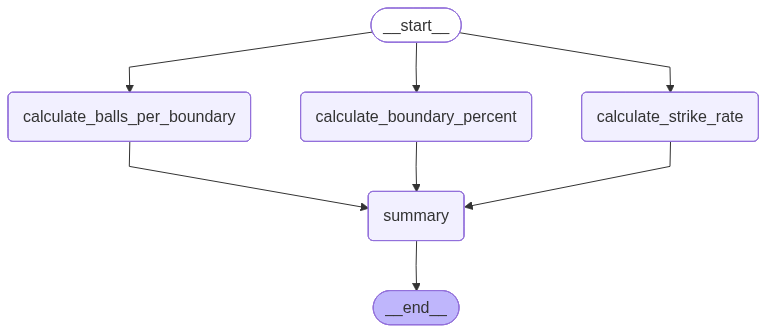

In [16]:
# view the graph
Image(compiled_graph.get_graph().draw_mermaid_png())

### 2. LLM Parallel Workflow Example
### UPSC Essay Evaluation  
```mermaid
graph TD
    A([START]) --> B([Clarity of Thought])
    A --> C([Depth of Analysis])
    A --> D([Language])
    B --> E([Final Evaluation])
    C --> E
    D --> E

    style A fill:#4CAF50,color:#fff
    style B fill:#2196F3,color:#fff
    style C fill:#2196F3,color:#fff
    style D fill:#2196F3,color:#fff
    style E fill:#F44336,color:#fff
```


#### the state for this graph should be as follows  
```json
{
    "essay_text": "str",
    "clarity_of_thought_feedback": "str",
    "depth_of_analysisi_feedback": "str",
    "language_feedback": "str",
    "individual_scores": "list",
    "final_avg_score": "float"
}
```

In [72]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from IPython.display import Image, Markdown, display
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
import operator
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pydantic")

In [73]:
load_dotenv()

True

In [74]:
llm = ChatOpenAI(model = "gpt-4o", temperature=0.7)

In [75]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Detailed Feedback on the essay.")
    score: int = Field(description="Score for the essay on a scale of 1 to 10.")

In [76]:
structured_model = llm.with_structured_output(EvaluationSchema)

In [52]:
with open("essay.txt", "r") as f:
    essay = f.read()

display(Markdown(essay))

India in the Age of AI
=======================
As the world enters a transformative era defined by artificial intelligence (AI), India stands at a critical juncture â€” one where it can either emerge as a global leader in AI innovation or risk falling behind in the technology race. The age of AI brings with it immense promise as well as unprecedented challenges, and how India navigates this landscape will shape its socio-economic and geopolitical future.

India's strengths in the AI domain are rooted in its vast pool of skilled engineers, a thriving IT industry, and a growing startup ecosystem. With over 5 million STEM graduates annually and a burgeoning base of AI researchers, India possesses the intellectual capital required to build cutting-edge AI systems. Institutions like IITs, IIITs, and IISc have begun fostering AI research, while private players such as TCS, Infosys, and Wipro are integrating AI into their global services. In 2020, the government launched the National AI Strategy (AI for All) with a focus on inclusive growth, aiming to leverage AI in healthcare, agriculture, education, and smart mobility.

One of the most promising applications of AI in India lies in agriculture, where predictive analytics can guide farmers on optimal sowing times, weather forecasts, and pest control. In healthcare, AI-powered diagnostics can help address Indiaâ€™s doctor-patient ratio crisis, particularly in rural areas. Educational platforms are increasingly using AI to personalize learning paths, while smart governance tools are helping improve public service delivery and fraud detection.

However, the path to AI-led growth is riddled with challenges. Chief among them is the digital divide. While metropolitan cities may embrace AI-driven solutions, rural India continues to struggle with basic internet access and digital literacy. The risk of job displacement due to automation also looms large, especially for low-skilled workers. Without effective skilling and re-skilling programs, AI could exacerbate existing socio-economic inequalities.

Another pressing concern is data privacy and ethics. As AI systems rely heavily on vast datasets, ensuring that personal data is used transparently and responsibly becomes vital. India is still shaping its data protection laws, and in the absence of a strong regulatory framework, AI systems may risk misuse or bias.

To harness AI responsibly, India must adopt a multi-stakeholder approach involving the government, academia, industry, and civil society. Policies should promote open datasets, encourage responsible innovation, and ensure ethical AI practices. There is also a need for international collaboration, particularly with countries leading in AI research, to gain strategic advantage and ensure interoperability in global systems.

Indiaâ€™s demographic dividend, when paired with responsible AI adoption, can unlock massive economic growth, improve governance, and uplift marginalized communities. But this vision will only materialize if AI is seen not merely as a tool for automation, but as an enabler of human-centered development.

In conclusion, India in the age of AI is a story in the making â€” one of opportunity, responsibility, and transformation. The decisions we make today will not just determine Indiaâ€™s AI trajectory, but also its future as an inclusive, equitable, and innovation-driven society."""

In [77]:
# test the structured output
prompt = PromptTemplate(
    template = 'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}',
    input_variables = ['essay']
)
formateds_prompt = prompt.format_prompt(essay=essay)
evaluation = structured_model.invoke(formateds_prompt)

In [78]:
display(Markdown(evaluation.feedback))

### Feedback

**Strengths:**
1. **Structure and Coherence:**
   - The essay is well-structured, with a clear introduction, body, and conclusion. Each section logically flows into the next, making the argument easy to follow.
   - The use of subheadings, like “India in the Age of AI,” helps in organizing the content and guiding the reader through the essay.

2. **Content and Depth:**
   - The essay provides a comprehensive overview of India's position in the AI landscape, discussing both strengths and challenges.
   - It covers various sectors where AI can be impactful, such as agriculture, healthcare, and education, demonstrating a broad understanding of AI applications.

3. **Language and Style:**
   - The vocabulary used is appropriate for an academic or professional essay, ensuring clarity and precision.
   - Sentences are well-constructed, and the varied sentence length maintains reader engagement.

**Areas for Improvement:**
1. **Punctuation and Typographical Errors:**
   - There are minor typographical errors, such as inconsistent use of apostrophes (e.g., "Indiaâ€™s" instead of “India’s”). These may distract readers and should be corrected for professionalism.

2. **Transition and Flow:**
   - While each paragraph is well-developed, adding smoother transition phrases between ideas could enhance the overall flow and cohesion of the essay.

3. **Depth of Analysis:**
   - The essay could delve deeper into how India plans to overcome the digital divide and address job displacement, providing specific examples or case studies.

4. **Conclusion Enhancement:**
   - The conclusion summarizes the main points well, but it could be strengthened by offering more specific recommendations or a call to action for stakeholders involved in AI development.

### Overall Impression
The essay successfully presents a balanced view of India’s potential and challenges in the AI era with clear insights and logical structuring. Addressing minor language issues and enhancing analytical depth could elevate its effectiveness.

### Score: 8/10

In [79]:
# state for UPSC essay evaluation
class UPSCState(TypedDict):
    essay_text: str
    clarity_of_thought_feedback: str
    depth_of_analysis_feedback: str
    language_quality_feedback: str
    overall_feedback: str
    individual_scores : Annotated[list[int], operator.add] # reducer function
    average_score: float

In [80]:
def evaluate_language_quality(state: UPSCState) -> UPSCState:
    prompt = PromptTemplate(
        template='Evaluate the language quality of the following essay and provide feedback and assign a score out of 10 \n {essay}',
        input_variables=['essay']
    )
    # Format the prompt first, then invoke structured model separately
    formatted_prompt = prompt.format(essay=state['essay_text'])
    evaluation = structured_model.invoke(formatted_prompt)  # direct invoke, no pipe chain
    return {
        'language_quality_feedback': evaluation.feedback,
        'individual_scores': [evaluation.score]
    }

def evaluate_clarity_of_thought(state: UPSCState) -> UPSCState:
    prompt = PromptTemplate(
        template='Evaluate the clarity of thought of the following essay and provide feedback and assign a score out of 10 \n {essay}',
        input_variables=['essay']
    )
    formatted_prompt = prompt.format(essay=state['essay_text'])
    evaluation = structured_model.invoke(formatted_prompt)
    return {
        'clarity_of_thought_feedback': evaluation.feedback,
        'individual_scores': [evaluation.score]
    }

def evaluate_depth_of_analysis(state: UPSCState) -> UPSCState:
    prompt = PromptTemplate(
        template='Evaluate the depth of analysis of the following essay and provide feedback and assign a score out of 10 \n {essay}',
        input_variables=['essay']
    )
    formatted_prompt = prompt.format(essay=state['essay_text'])
    evaluation = structured_model.invoke(formatted_prompt)
    return {
        'depth_of_analysis_feedback': evaluation.feedback,
        'individual_scores': [evaluation.score]
    }


def final_evaluation(state: UPSCState) -> UPSCState:

    # summary feedback
    prompt = PromptTemplate(
        template = 'Based on the following feedbacks create a summarized feedback \n language feedback - {language_feedback} \n depth of analysis feedback - {depth_of_analysis_feedback} \n clarity of thought feedback - {clarity_of_thought_feedback}',
        input_variables = ['language_feedback', 'depth_of_analysis_feedback', 'clarity_of_thought_feedback']
    )
    formatted_prompt = prompt.format(
        language_feedback=state["language_quality_feedback"],
        depth_of_analysis_feedback=state["depth_of_analysis_feedback"],
        clarity_of_thought_feedback=state["clarity_of_thought_feedback"]
    )
    summary = llm.invoke(formatted_prompt)

    # avg score
    avg_score = sum(state["individual_scores"]) / len(state["individual_scores"])
    return {
        "overall_feedback": summary.content,
        "average_score": avg_score
    }

In [81]:
# graph
graph = StateGraph(UPSCState)

graph.add_node("evaluate_clarity_of_thought", evaluate_clarity_of_thought)
graph.add_node("evaluate_depth_of_analysis", evaluate_depth_of_analysis)
graph.add_node("evaluate_language_quality", evaluate_language_quality)
graph.add_node("final_evaluation", final_evaluation)

graph.add_edge(START, "evaluate_clarity_of_thought")
graph.add_edge(START, "evaluate_depth_of_analysis")
graph.add_edge(START, "evaluate_language_quality")
graph.add_edge("evaluate_clarity_of_thought", "final_evaluation")
graph.add_edge("evaluate_depth_of_analysis", "final_evaluation")
graph.add_edge("evaluate_language_quality", "final_evaluation")
graph.add_edge("final_evaluation", END)

compiled_graph = graph.compile()

In [82]:
initial_state = {
    "essay_text": essay
}

output_state = compiled_graph.invoke(initial_state)


display(Markdown(output_state['overall_feedback']))
print(f"Average Score: {output_state['average_score']:.2f}")

**Summarized Feedback**

**Overall Impression:**
The essay "India in the Age of AI" is a well-structured and insightful exploration of India's potential and challenges in the AI sector. It effectively balances optimism with a realistic view of the hurdles ahead, offering a clear and coherent narrative throughout.

**Strengths:**
1. **Clarity and Structure:** The essay is logically organized, with a clear introduction, detailed analysis of opportunities and challenges, and a forward-looking conclusion. This structure enhances readability and understanding.
   
2. **Use of Evidence and Contextual Understanding:** The incorporation of facts, such as India's National AI Strategy and the number of STEM graduates, lends credibility. The essay also provides a comprehensive overview of AI's applications in sectors like agriculture, healthcare, and governance.

3. **Balanced and Nuanced Perspective:** Acknowledging both opportunities and risks, such as inequality and job displacement, the essay presents a nuanced understanding of AI's socio-economic implications.

4. **Vocabulary and Clarity of Thought:** The language is formal yet accessible, using relevant AI and technology terms effectively. The essay maintains a clear and logical flow, with each section reinforcing the central thesis.

**Areas for Improvement:**
1. **Character Consistency:** Addressing encoding issues with non-standard characters would enhance professionalism.

2. **Depth of Analysis in Challenges:** Expanding on challenges like digital literacy and privacy, and incorporating examples or case studies, would deepen the analysis.

3. **Comparative and Policy Analysis:** A brief comparison with global AI leaders and more detail on India's data protection laws could provide additional insights.

4. **Call to Action:** Strengthening the conclusion with a more urgent call to action could better motivate stakeholders to address the discussed challenges.

**Final Thoughts:**
With minor refinements, particularly in character consistency and depth of analysis, the essay could serve as a compelling resource for policymakers, educators, and industry leaders. It scores highly for its clarity and balanced viewpoint, with room for enhanced analytical depth and evidence.

**Overall Score: 8.5/10**

Average Score: 8.33


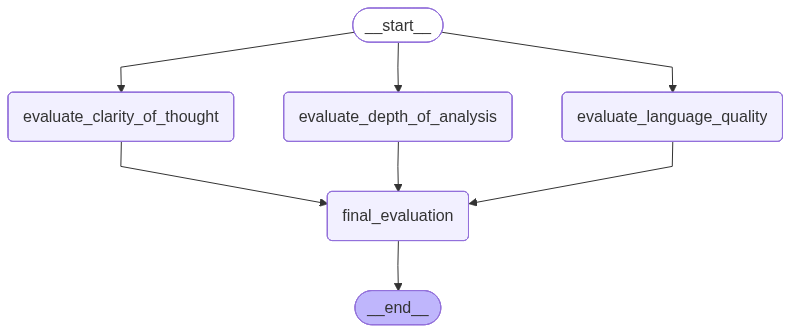

In [83]:
compiled_graph